In [2]:
!pip -q install xarray netcdf4 h5netcdf cartopy

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore")

BASE = Path("/content")
DATA_DIR = BASE / "data"
FIG_DIR = BASE / "figures"

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

In [3]:
from google.colab import files

event_file = DATA_DIR / "derived_event_list.csv"

if not event_file.exists():
    print("Upload derived_event_list.csv from the main recurvature notebook.")
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    uploaded_path = Path("/content") / uploaded_name
    uploaded_path.rename(event_file)

events = pd.read_csv(event_file)

print(events.shape)
print(events.columns.tolist())
events.head()

Upload derived_event_list.csv from the main recurvature notebook.


Saving baseline_zonal_events_600km.csv to baseline_zonal_events_600km.csv
(167, 19)
['sid', 'season', 'name', 'detector', 'distance_threshold_km', 'lat_gate_degN', 'window_steps', 'zonal_threshold_km_6h', 'zonal_pre_max_km_6h', 'recurv_i', 'recurv_original_time_index', 'recurv_time', 'recurv_lat', 'recurv_lon', 'box_hit', 'min_dist_km', 'closest_proxy_idx', 'closest_proxy', 'nl_relevant']


,sid,season,name,detector,distance_threshold_km,lat_gate_degN,window_steps,zonal_threshold_km_6h,zonal_pre_max_km_6h,recurv_i,recurv_original_time_index,recurv_time,recurv_lat,recurv_lon,box_hit,min_dist_km,closest_proxy_idx,closest_proxy,nl_relevant
0,1950224N17305,1950,ABLE,zonal,600.0,25.0,4,30.0,30.0,64,64,1950-08-20 00:00:00.000040448,32.799999,-75.199997,True,26.364536,1,Corner Brook region (west coast),True
1,1950234N11334,1950,CHARLIE,zonal,600.0,25.0,4,30.0,30.0,107,107,1950-09-03 21:00:00.000040448,36.434937,-60.437199,False,483.520455,0,St. John's (Avalon Peninsula),True
2,1950243N15304,1950,DOG,zonal,600.0,25.0,4,30.0,30.0,95,95,1950-09-11 15:00:00.000040448,37.179321,-71.731087,False,551.890771,0,St. John's (Avalon Peninsula),True
3,1950270N25309,1950,GEORGE,zonal,600.0,25.0,4,30.0,30.0,54,54,1950-10-04 00:00:00.000040448,34.200001,-68.000000,True,120.532233,0,St. John's (Avalon Peninsula),True
4,1952231N15341,1952,ABLE,zonal,600.0,25.0,4,30.0,30.0,108,108,1952-08-31 18:00:00.000040448,35.400002,-80.599998,False,410.074933,1,Corner Brook region (west coast),True


In [4]:
def pick_col(df, candidates, required=True):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    if required:
        raise ValueError(
            f"Could not find any of these columns: {candidates}\n"
            f"Available columns: {df.columns.tolist()}"
        )
    return None

sid_col = pick_col(events, ["sid", "SID", "storm_id"], required=False)
name_col = pick_col(events, ["name", "storm_name"], required=False)
season_col = pick_col(events, ["season", "year"], required=True)
time_col = pick_col(events, ["recurv_time", "recurvature_time", "turn_time"], required=True)
detector_col = pick_col(events, ["detector", "method", "recurv_detector"], required=False)

events = events.copy()
events["season"] = events[season_col].astype(int)
events["recurv_time"] = pd.to_datetime(events[time_col], errors="coerce", utc=True)

if detector_col is not None:
    mask_detector = events[detector_col].astype(str).str.lower().str.contains("zonal|baseline", na=False)
    if mask_detector.any():
        events = events[mask_detector].copy()

events_ncep = events[
    (events["season"] >= 1979) &
    (events["season"] <= 2023) &
    events["recurv_time"].notna()
].copy()

# NCEP/NCAR Reanalysis is 4-times daily: 00, 06, 12, 18 UTC.
# Round recurvature time to nearest 6-hour synoptic time.
events_ncep["ncep_time"] = events_ncep["recurv_time"].dt.round("6h")
events_ncep["ncep_year"] = events_ncep["ncep_time"].dt.year
events_ncep["ncep_month"] = events_ncep["ncep_time"].dt.month
events_ncep["ncep_hour"] = events_ncep["ncep_time"].dt.hour

events_ncep.to_csv(DATA_DIR / "physical_context_events_1979_2023_ncep.csv", index=False)

print(f"Satellite-era baseline events used for NCEP composite: {len(events_ncep)}")
events_ncep[["season", "recurv_time", "ncep_time"]].head()

Satellite-era baseline events used for NCEP composite: 97


,season,recurv_time,ncep_time
70,1979,1979-08-04 12:00:00.000040448+00:00,1979-08-04 12:00:00+00:00
71,1979,1979-09-05 21:00:00.000040448+00:00,1979-09-06 00:00:00+00:00
72,1980,1980-09-06 15:00:00.000040448+00:00,1980-09-06 18:00:00+00:00
73,1981,1981-09-03 15:00:00.000040448+00:00,1981-09-03 18:00:00+00:00
74,1982,1982-09-14 21:00:00.000040448+00:00,1982-09-15 00:00:00+00:00


In [5]:
# NOAA PSL THREDDS/OPeNDAP URLs.
# Annual 4-times-daily pressure-level geopotential height:
# hgt.YYYY.nc
NCEP_ANNUAL_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.{year}.nc"

# Monthly mean pressure-level geopotential height:
NCEP_MONTHLY_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis.derived/pressure/hgt.mon.mean.nc"

# Domain: 20–75N, 100W–0W.
# NCEP longitudes use 0–360, so 100W–0W = 260E–360E.
LAT_SLICE = slice(75, 20)       # NCEP latitude is usually descending
LON_SLICE = slice(260, 357.5)   # close to 100W–0W
LEVEL = 500

def standardize_hgt(ds):
    da = ds["hgt"]

    # Some files use level, some may use named coords consistently.
    if "level" in da.dims or "level" in da.coords:
        da = da.sel(level=LEVEL)

    da = da.sel(lat=LAT_SLICE, lon=LON_SLICE)

    da.name = "z500"
    da.attrs["units"] = "m"

    return da

def to_naive_utc(ts):
    ts = pd.Timestamp(ts)
    if ts.tzinfo is not None:
        ts = ts.tz_convert("UTC").tz_localize(None)
    return np.datetime64(ts)

def lon_to_180(da):
    lon = (((da["lon"] + 180) % 360) - 180)
    da = da.assign_coords(lon=lon).sortby("lon")
    return da

In [6]:
print("Opening NCEP/NCAR monthly mean geopotential height file...")
ds_mon = xr.open_dataset(NCEP_MONTHLY_URL)

z_mon = standardize_hgt(ds_mon)

# Restrict to 1991–2020 climatology.
z_mon_9120 = z_mon.sel(time=slice("1991-01-01", "2020-12-31"))

# Monthly climatology: one field for each calendar month.
z_clim = z_mon_9120.groupby("time.month").mean("time").load()

print(z_clim)

Opening NCEP/NCAR monthly mean geopotential height file...
<xarray.DataArray 'z500' (month: 12, lat: 23, lon: 40)> Size: 44kB
array([[[5034.9746, 5029.045 , 5023.82  , ..., 5148.598 , 5149.736 ,
         5150.795 ],
        [5043.679 , 5035.736 , 5028.6377, ..., 5175.811 , 5177.503 ,
         5179.0703],
        [5058.942 , 5048.683 , 5039.398 , ..., 5206.111 , 5208.6675,
         5211.005 ],
        ...,
        [5811.3345, 5814.103 , 5817.4316, ..., 5777.455 , 5774.107 ,
         5771.0684],
        [5835.0425, 5837.859 , 5840.909 , ..., 5798.326 , 5796.9263,
         5795.7964],
        [5850.8784, 5853.632 , 5856.169 , ..., 5820.049 , 5820.2793,
         5820.6074]],

       [[5051.4097, 5044.6714, 5038.4653, ..., 5161.727 , 5162.6597,
         5163.3213],
        [5058.67  , 5049.8115, 5041.6997, ..., 5185.7886, 5187.228 ,
         5188.3247],
        [5072.0483, 5060.9644, 5050.673 , ..., 5212.11  , 5214.4067,
         5216.2925],
...
        [5854.5103, 5855.4014, 5856.591 , ...

In [7]:
event_ds_cache = {}
anomaly_list = []
meta_rows = []

for year, group in events_ncep.groupby("ncep_year"):
    url = NCEP_ANNUAL_URL.format(year=int(year))
    print(f"Opening {year}: {url}")

    ds_year = xr.open_dataset(url)
    z_year = standardize_hgt(ds_year)

    # Load only the subset of event times needed for this year.
    needed_times = sorted(group["ncep_time"].map(to_naive_utc).unique())
    z_subset = z_year.sel(time=needed_times, method="nearest").load()

    for idx, row in group.iterrows():
        event_time = to_naive_utc(row["ncep_time"])
        month = int(row["ncep_month"])

        event_field = z_subset.sel(time=event_time, method="nearest")
        clim_field = z_clim.sel(month=month)

        anomaly = event_field - clim_field
        anomaly = anomaly.squeeze(drop=True).reset_coords(drop=True)

        anomaly_list.append(anomaly)

        meta_rows.append({
            "season": row.get("season", np.nan),
            "sid": row.get(sid_col, "") if sid_col is not None else "",
            "name": row.get(name_col, "") if name_col is not None else "",
            "recurv_time": row["recurv_time"],
            "ncep_time": row["ncep_time"],
            "month": month,
            "hour": int(row["ncep_hour"]),
        })

anom_stack = xr.concat(anomaly_list, dim=pd.Index(range(len(anomaly_list)), name="event"))

z500_anom_composite = anom_stack.mean("event")
z500_anom_composite = lon_to_180(z500_anom_composite)

z500_anom_composite.name = "z500_anomaly_composite"
z500_anom_composite.attrs["long_name"] = "Composite 500-hPa geopotential height anomaly"
z500_anom_composite.attrs["units"] = "m"

out_nc = DATA_DIR / "composite_z500_anomaly_recurvature_1979_2023_ncep.nc"
z500_anom_composite.to_netcdf(out_nc)

pd.DataFrame(meta_rows).to_csv(DATA_DIR / "physical_context_composite_event_metadata_ncep.csv", index=False)

print(f"Composite saved to: {out_nc}")
print(f"Events composited: {len(anomaly_list)}")
print(f"Composite min/max: {float(z500_anom_composite.min()):.1f}, {float(z500_anom_composite.max()):.1f} m")

Opening 1979: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1979.nc
Opening 1980: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1980.nc
Opening 1981: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1981.nc
Opening 1982: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1982.nc
Opening 1984: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1984.nc
Opening 1985: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1985.nc
Opening 1988: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1988.nc
Opening 1989: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1989.nc
Opening 1990: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1990.nc
Opening 1991: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/hgt.1991.nc
Opening 1992: https://psl.noaa.gov/thredds/dodsC/D

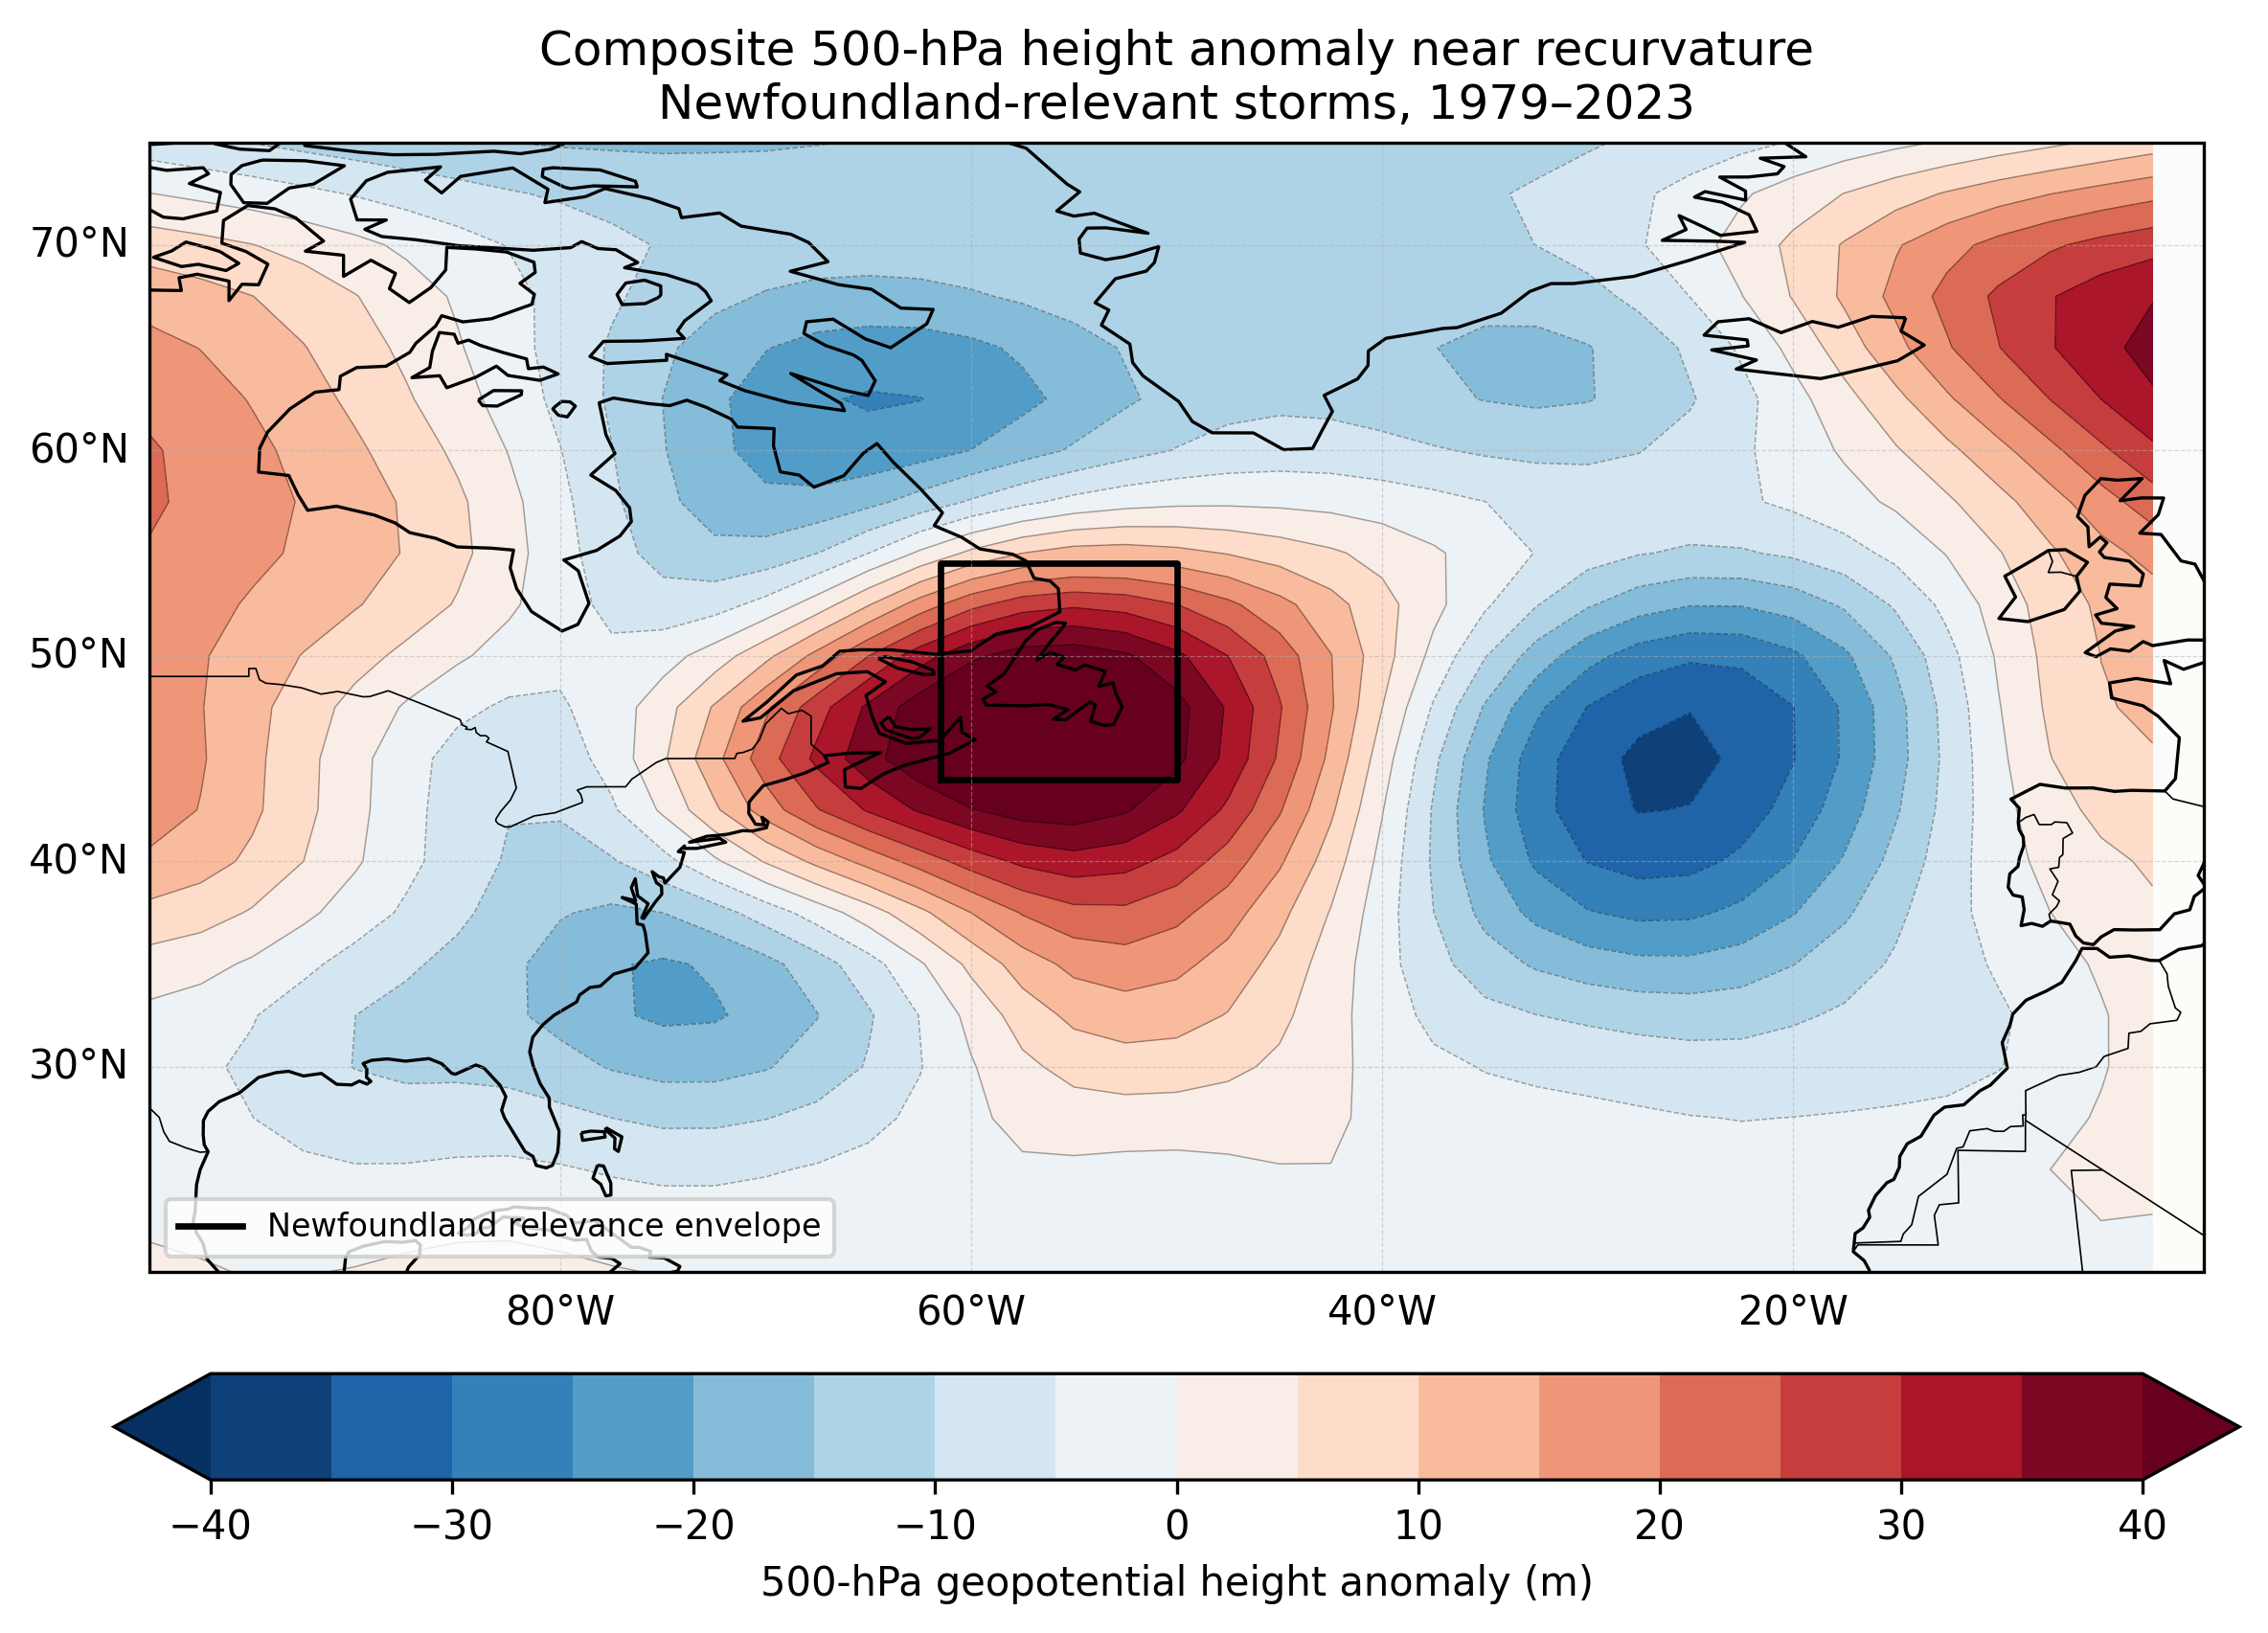

Figure saved to: /content/figures/fig10_z500_composite.png


In [8]:
comp = z500_anom_composite

lat = comp["lat"]
lon = comp["lon"]

vmax = float(np.nanpercentile(np.abs(comp.values), 98))
vmax = max(20, np.ceil(vmax / 10) * 10)
levels = np.linspace(-vmax, vmax, 17)

fig = plt.figure(figsize=(9.0, 5.8), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-100, 0, 20, 75], crs=ccrs.PlateCarree())

cf = ax.contourf(
    lon,
    lat,
    comp,
    levels=levels,
    extend="both",
    cmap="RdBu_r",
    transform=ccrs.PlateCarree()
)

ax.contour(
    lon,
    lat,
    comp,
    levels=levels,
    linewidths=0.35,
    colors="black",
    alpha=0.35,
    transform=ccrs.PlateCarree()
)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)
ax.add_feature(cfeature.OCEAN, alpha=0.05)

# Newfoundland relevance envelope
nfld_lon_min, nfld_lon_max = -61.5, -50.0
nfld_lat_min, nfld_lat_max = 44.0, 54.5

ax.plot(
    [nfld_lon_min, nfld_lon_max, nfld_lon_max, nfld_lon_min, nfld_lon_min],
    [nfld_lat_min, nfld_lat_min, nfld_lat_max, nfld_lat_max, nfld_lat_min],
    linewidth=1.6,
    color="black",
    transform=ccrs.PlateCarree(),
    label="Newfoundland relevance envelope"
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

cb = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.07, shrink=0.86)
cb.set_label("500-hPa geopotential height anomaly (m)")

ax.set_title(
    "Composite 500-hPa height anomaly near recurvature\n"
    "Newfoundland-relevant storms, 1979–2023"
)

ax.legend(loc="lower left", fontsize=8)

fig.tight_layout()

out_png = FIG_DIR / "fig10_z500_composite.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_png}")

In [9]:
diag = pd.DataFrame(meta_rows)

print("Events by month:")
print(diag["month"].value_counts().sort_index())

print("\nEvents by synoptic hour:")
print(diag["hour"].value_counts().sort_index())

print(f"\nN events in composite: {len(diag)}")

Events by month:
month
6      3
7     16
8     19
9     41
10    16
11     2
Name: count, dtype: int64

Events by synoptic hour:
hour
0     17
6     31
12    22
18    27
Name: count, dtype: int64

N events in composite: 97
